# Weekly project 3

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

plt.gray()

<Figure size 640x480 with 0 Axes>

In [12]:
# Load grayscale images
nose_left = cv2.imread("nose_left.png", cv2.IMREAD_GRAYSCALE)
nose_right = cv2.imread("nose_right.png", cv2.IMREAD_GRAYSCALE)


def SAD(img1, img2):
    # Convert to signed integers BEFORE subtraction to avoid mistakes
    img1 = img1.astype(np.int16)
    img2 = img2.astype(np.int16)
    assert img1.shape == img2.shape, "Images must have the same shape"

    difference = np.abs(img1 - img2)

    return np.sum(difference)


sad_value = SAD(nose_left, nose_right)


print("SAD between nose_left and nose_right:", sad_value)

SAD between nose_left and nose_right: 7657


In [13]:
nose1 = cv2.imread("nose1.png", cv2.IMREAD_GRAYSCALE)
nose2 = cv2.imread("nose2.png", cv2.IMREAD_GRAYSCALE)
nose3 = cv2.imread("nose3.png", cv2.IMREAD_GRAYSCALE)
nose_span=cv2.imread("nose_span.png",cv2.IMREAD_GRAYSCALE)

sad1 = SAD(nose_left, nose1)
sad2 = SAD(nose_left, nose2)
sad3 = SAD(nose_left, nose3)

print("SAD nose1:", sad1)
print("SAD nose2:", sad2)
print("SAD nose3:", sad3)

SAD nose1: 1361
SAD nose2: 119
SAD nose3: 1490


In [14]:
scores = [sad1, sad2, sad3]

best = np.argmin(scores)

print("Best match: nose" + str(best + 1))

Best match: nose2


In [15]:
print(nose_left.shape)
print(nose_span.shape)

(7, 7)
(7, 384)


In [16]:
nose_span = cv2.imread("nose_span.png", cv2.IMREAD_GRAYSCALE)

template_width = nose_left.shape[1]
span_width = nose_span.shape[1]

scores = []

for x in range(span_width - template_width + 1):

    # Extract a 7x7 block
    candidate = nose_span[
        :,
        x:x + template_width
    ]

    # Compare against the template
    score = SAD(nose_left, candidate)

    scores.append(score)


# Position with smallest SAD
best_x = np.argmin(scores)

print("Best x position:", best_x)
print("Minimum SAD:", scores[best_x])

Best x position: 132
Minimum SAD: 119


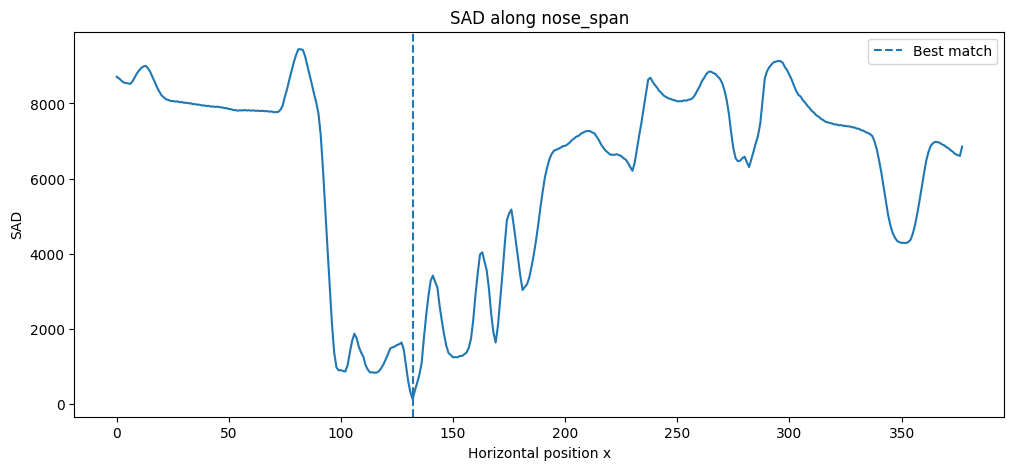

In [17]:
plt.figure(figsize=(12,5))

plt.plot(scores)

plt.axvline(
    best_x,
    linestyle="--",
    label="Best match"
)

plt.xlabel("Horizontal position x")
plt.ylabel("SAD")
plt.title("SAD along nose_span")
plt.legend()

plt.show()  

## Full template matching with SAD
For each 7x7 patch in the left image, search every possible 7x7 patch along the corresponding row in the right image. We reuse `SAD` to choose the match with the smallest score.

Disparity is the horizontal displacement `x_left - x_right`, not the SAD score. Store it at the centre of the left patch. The three-pixel border stays `NaN` because a complete patch cannot be centred there. Searching the entire row with Python loops can take a few minutes.

In [20]:
def template_matching(left, right):
    if left is None or right is None:
        raise ValueError("Could not load both images. Check the image paths.")
    if left.shape != right.shape or left.ndim != 2:
        raise ValueError("Images must be grayscale and have the same shape.")

    window_size = 7
    radius = window_size // 2
    height, width = left.shape
    if height < window_size or width < window_size:
        raise ValueError("Images must be at least 7x7 pixels.")

    disparity = np.full((height, width), np.nan, dtype=np.float32)

    # Finish all left templates in one row before moving down.
    for y in range(height - window_size + 1):
        for x_left in range(width - window_size + 1):
            template = left[y:y + window_size, x_left:x_left + window_size]
            scores = []

            # Same y: search horizontally in the right image.
            for x_right in range(width - window_size + 1):
                candidate = right[y:y + window_size, x_right:x_right + window_size]
                scores.append(SAD(template, candidate))

            # As in the nose example, ties select the first minimum.
            best_x_right = np.argmin(scores)
            disparity[y + radius, x_left + radius] = x_left - best_x_right

    return disparity

In [32]:
tsukuba_left = cv2.imread("tsukuba_left.png", cv2.IMREAD_GRAYSCALE)
tsukuba_right = cv2.imread("tsukuba_right.png", cv2.IMREAD_GRAYSCALE)

disparity = template_matching(tsukuba_left, tsukuba_right)

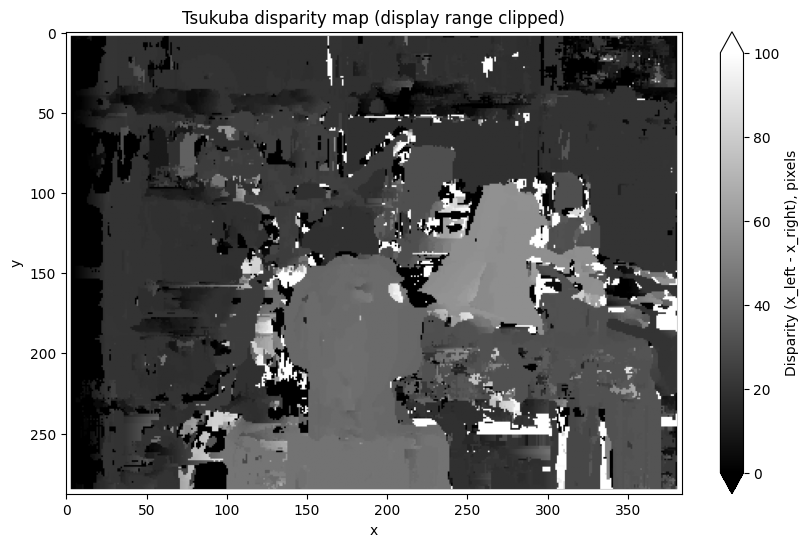

In [33]:
# Adjust these display limits without recalculating the disparity map.
# Values below 0 or above 16 use the endpoint colors.
disparity_min = 0
disparity_max = 100

plt.figure(figsize=(10, 6))
plt.imshow(
    np.ma.masked_invalid(disparity),
    cmap="gray",
    vmin=disparity_min,
    vmax=disparity_max,
)
plt.colorbar(label="Disparity (x_left - x_right), pixels", extend="both")
plt.title("Tsukuba disparity map (display range clipped)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [ ]:
def export_pointcloud(disparity_map, colors):
    ply_header = '''ply
    format ascii 1.0
    element vertex %(vert_num)d
    property float x
    property float y
    property float z
    property uchar red
    property uchar green
    property uchar blue
    end_header
    '''

    def write_ply(fn, verts, colors):
        verts = verts.reshape(-1, 3)
        colors = colors.reshape(-1, 3)
        verts = np.hstack([verts, colors])
        with open(fn, 'wb') as f:
            f.write((ply_header % dict(vert_num=len(verts))).encode('utf-8'))
            np.savetxt(f, verts, fmt='%f %f %f %d %d %d ')

    h, w = disparity_map.shape[:2]
    # Guess for focal length. If you 3D reconstruction looks skewed in the
    # viewing direction, try adjusting this parameter.
    f = .8 * w
    Q = np.float32([[1, 0, 0, -0.5 * w],
                    [0, -1, 0, 0.5 * h],  # turn points 180 deg around x-axis,
                    [0, 0, 0, -f],  # so that y-axis looks up
                    [0, 0, 1, 0]])
    points = cv2.reprojectImageTo3D(disparity_map, Q)

    mask = disparity_map > disparity_map.min()

    print(disparity_map.min())
    print(disparity_map[mask].min())

    out_points = points[mask]
    out_colors = colors[mask]
    out_fn = 'out.ply'
    write_ply('out.ply', out_points, out_colors)
    print(f'{out_fn} saved')

export_pointcloud(disparity_map=disparity, colors=tsukuba_left)

AttributeError: 'tuple' object has no attribute 'zeros'